In [1]:
import requests
from IPython.core.display import HTML
HTML(f"""
<style>
</style>
""")

# Experimenting with the tutorial

**Overview**
This exercise is related to the week 4 tutorial.
 
The individual tasks will ask you to either reflect on parts of the tutorial or modify specific code cells from the tutorial. Specifically, [Task 2](#project) and [Task 3](#ls) require modifications to the code of the tutorial notebook.
 


<article class="message">
    <div class="message-body">
        <strong>List of tasks</strong>
        <ul style="list-style: none;">
            <li>
            <a href="#copy">Task 1: Copy notebook</a>
            </li>
            <li>
            <a href="#project">Task 2: Projection experiments</a>
            </li>
            <li>
            <a href="#ls">Task 3: Linear Least Squares Experiments</a>
            </li>
            <li>
            <a href="#ls1">Task 4: Linear Least Squares Reflections</a>
            </li>
            <li>
            <a href="#poly">Task 5: Second-order polynomial</a>
            </li>
            <li>
            <a href="#pmatrix">Task 6: Projection matrix</a>
            </li>
        </ul>
    </div>
</article>


---
**Task 1 (easy): Copy notebook**
Copy the tutorial notebook
 in the repository. 
This makes it easy to go back to the original in case something goes wrong.

---
---
**Task 2 (easy): Projection experiments👩‍💻📽️**
This task builds on the $\textbf{Projections}$ section in the tutorial.
1. Search and identify comment `##1`
. 
2. Change the values of the matrix $A$ (below comment `##1`
) to modify the line. Experiment with different values and observe how the projection changes in the plot.
3. Change the matrix $A$, such that $PX$ ≈ $X$ (that is the projection leaves $X$ almost unchanged). 
4. Search and identify comment `##2`
.
5. Set the matrix $A$  = $\begin{bmatrix} 1 \\ 0.5 \end{bmatrix}$, then apply the projection matrix $P$ twice, i.e. calculate $PPX$ (just below the comment). How does this affect the projected points?


---

## Answer
### 1
If we change A, so that the vector fx is (1,1) and the line is y=a*1 then the line shown has a different slope, and the projections onto the line will change.

### 2
For PX ≈ X then P should be the identity matrix *I*, this is hard to write as a linear function.

### 5
PP = P, so the projected points don't change. P is an idempotent matrix. This is the definition of a projection matrix.



---
**Task 3 (easy): Linear Least Squares Experiments👩‍💻**
This task builds on the $\textbf{Linear Least Squares}$ section in the tutorial.
1. Search and identify comment `##3`
.
2. Change the values of the first point in the matrix `X`
 such that it gradually moves further and further away from the line. Observe how it affects the error $RMS$.
3. Add two points to `X`
 and observe how they affect the fitted line and the error.


---

## Answer

### 1
Before we change the values of X RMS = 0.40824829046386285
if we change the first value to (1,0) then RMS = 0.8164965809277259
if we change the first value to (20,50) then RMS = 1.9371223494510281

### 2
We added two points (4, 1.5) and (0, 3), now the line is very different and the RMS = 1.3416407864998738


---
**Task 4 (easy): Linear Least Squares Reflections💡📽️**
1. How can you change the two additional points so the fitted line does not move?
2. What happens to the error when removing all but two points from `X`
?
3. What happens when you remove all but one point from `X`
?
4. Reflect on how the quality of the data affects the projection and thus the solution. 


---

## Answer
### 1
Then we need to find two points that are on the line created by the first points we were given, fx the point (4, 2.7)

### 2
The error is zero, or vero close to zero, because then the line created is just a line through the two points.

### 3
If we inly have one point, then we have a matrix where the determinant is equal to zero, and it is therefore imposible to frind the inverse of the matrix.

### 4
If the data points are very scattered, i.e. noisy data then the RMS is higher because it it harder to find a line that fits all the data points. 

## Pen and paper exercises
A 2. order polynomial is given by 

$$f(x) = w_0 + w_1x + w_2x^2 = \sum^2_{i=0} w_ix^i.$$

Generally, an $N$'th order  polynomial is given by

$$f(x) = \sum^N_{i=0} w_ix^i,$$
where $\mathbb{w}$ is a vector of coefficients.

---
**Task 5 (medium): Second-order polynomial♾️📽️**
1. Identify the knowns and unknowns in the polynomial above.
2. Is the function linear or non-linear in $\mathbb{w}$?
3. Is the function linear or non-linear in $\mathbb{x}$?
4. Provide the outline of an algorithm for fitting a second-order polynomial using linear least squares.
5. Generalize this algorithm to n-th order polynomials.


---

## Answers
### 1
The unknowns are the weights, i.e $w_0,w_1, w_2$ and the known is the $x$ and the $f(x)/y$

### 2
The function is linear in $w$ 

### 3
The function is non-linear in $x$ because we use $x^2$

### 4
To fit a 2nd order polynomial we would have to change the design matrix to include and extra coulmn with $x^2$, then we could find the weights in the same way as with the linear model, and we would get three weights instead of two. 
See code example below

### 5
Add a coulmn for each extra order in the design matrix. (Make some sort of loop)



A
 [[1. 1. 1.]
 [4. 2. 1.]
 [9. 3. 1.]]
w: [-0.5  2.5 -1. ]


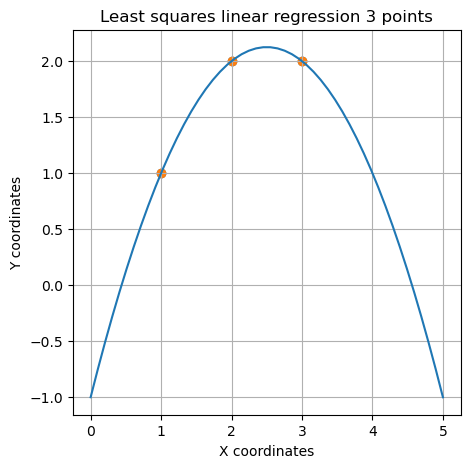

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([
    [1, 1],
    [2, 2],
    [3, 2]
]).T

x_vals = X[0, :]
y_vals = X[1, :]

A = np.vstack((x_vals**2, x_vals, np.ones(x_vals.shape))).T
print("A\n", A)

P = np.linalg.inv(A.T @ A) @ A.T
# Applying the transformation
w = P @ y_vals
print("w:", w)

# Calculating the projected y-values
y_hat = A @ w

x = np.linspace(0, 5)  # Create range of values
y = x**2 * w[0] + x * w[1] + w[2]   # Calculate f(x)


plt.figure(figsize=(5, 5))

plt.plot(x, y)  # Plot line
plt.scatter(X[0, :], X[1, :])  # Plot original points

plt.scatter(X[0, :], y_hat)  # Plot the points
plt.title('Least squares linear regression 3 points')
plt.xlabel("X coordinates")
plt.ylabel("Y coordinates")
plt.grid(True)
plt.show()



---
**Task 6 (medium): Projection matrix♾️**
The projection matrix $P = A(A^\top A )^{-1}A^\top$ is, under certain conditions, equal to the identity matrix.
1. Give an example of a design matrix $A$ for which $P=I$.
2. Explain why projection matrices are usually not identity matrices.
3. (optional) Prove a condition for which $P=I$. Hint: when is $A^\top A=I$?.


---

## Answer
### 1
$I = A(A^TA)^{-1}A^T$
So the design matrix could be:
$$ 
\begin{bmatrix}
    2 & 1 \\
    1 & 1
\end{bmatrix}
$$
When A is invertable, P is the identity matrix. P is the pseudo inverse.

### 2
Because a projection matrix is mostly used when the desing matrix is not square (and therefore not invertable). This means that the projection matrix can't be the identity matrix. 

### 3
$I = A(A^TA)^{-1}A^T$
If the matrix A an orthogonal matrix then $A^\top A = I$ 
$$I = A(A^\top A)^{-1}A^\top$$
$$I = A(I)^{-1}A^\top$$
$$I = AIA^\top$$
$$I = AA^\top$$




In [6]:
A = np.array([
    [2, 1],
    [1, 1]
])

P = (A @ np.linalg.inv(A.T @ A)) @ A.T
print("P:\n", P)
print(np.isclose(P, np.identity(P.shape[0])))

P:
 [[ 1.0000000e+00 -4.4408921e-16]
 [-8.8817842e-16  1.0000000e+00]]
[[ True  True]
 [ True  True]]
